# scTRAM Benchmarking for HDCA (Human Developmental Cell Atlas)

In [1]:
0

0

In [2]:
import sys

working_directory = "/home/icb/kemal.inecik/work/codes/sctram"
sys.path.append(working_directory)

import gc
import itertools
import logging
import os
import pickle
import subprocess
import sqlite3
import time
import h5py

from pandas.api.types import is_object_dtype
import anndata as ad
import networkx as nx
import numpy as np
import pandas as pd
import scanpy as sc
import tqdm
from math import sqrt

sc.settings.verbose = 3

In [3]:
from helper.get_hdca_trainings_with_paths import get_hdca_trainings_with_paths
from helper.pickle_operations import save_pickle_bundle, load_pickle_bundle
from helper.csv_operations import (
    harmonize_union_with_report,
    analyze_column_consistency,
    combine_dataframes_on_columns
)

from sctram.api._lower_level import TrajectoryEvaluationAPI
from sctram.generate.real import sc_suo_developmental_complete
from sctram.input import InputTrajectories

sys.path.append("/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments")
from incremental_training.helper.constants import metrics_scib, metric_direction_dict

2025-07-30 18:08:29.996 | INFO     | sctram.api._defaults_read:load_default_metrics:23 - Loaded default metrics from /home/icb/kemal.inecik/work/codes/sctram/sctram/api/_defaults.yaml
2025-07-30 18:08:30.071 | INFO     | sctram.api._defaults_read:load_default_metrics:79 - Default metrics YAML structure validated successfully.


In [4]:
# Important to have consistent figures across platforms

%matplotlib inline
%config InlineBackend.figure_format='retina'

import pickle

import colorcet as cc
import matplotlib.patheffects as path_effects
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text
from matplotlib import gridspec
from networkx.drawing.nx_agraph import graphviz_layout

from networkx.drawing.nx_agraph import graphviz_layout
from matplotlib import gridspec
import matplotlib.pyplot as plt
import matplotlib as mpl
import matplotlib.patches as mpatches
import seaborn as sns
import colorcet as cc
from matplotlib.ticker import FormatStrFormatter
from adjustText import adjust_text  
import matplotlib.patheffects as path_effects

_rcparams_path = os.path.join(working_directory, "reproducibility/figure_rcparams/rcparams.pickle")
with open(_rcparams_path, "rb") as file:
    _rcparams = pickle.load(file)
plt.rcParams.update(_rcparams)

In [5]:
def is_job_running(job_name):
    result = subprocess.run(
        ["squeue", "-o", "%.28i %.28j %.28u %R", "-u", "kemal.inecik"], capture_output=True, text=True
    )
    jobs = [[j.strip() for j in i.split()] for i in result.stdout.strip().split("\n")]
    for jobid, jobname, jobuser, jobnode in jobs:
        if job_name == jobname:
            return True
    return False

In [6]:
os.getcwd()

'/ictstr01/home/icb/kemal.inecik/work/codes/sctram/reproducibility/server_sync/experiments/development_atlas_figure'

In [7]:
dataset_dir = "/home/icb/kemal.inecik/lustre_workspace/temp_sctram_data"
helpers_directory = os.path.join(os.getcwd(), "helper")
logs_directory = os.path.join(os.getcwd(), "logs")

In [8]:
pickle_bundle_path = os.path.join(dataset_dir, "_experiment_development_atlas_helper_pickle_bundle.pkl")
(
    df_hdca_component_adata_paths,
    df_hdca_lvl3_adata_paths,
    out_df,
    ground_truth_trajectories,
    ground_truth_trajectories_annotation_level,
    trajectory_subset_dict
) = load_pickle_bundle(pickle_bundle_path)

In [9]:
def rank_metrics(df, metric_direction_dict, metric_index_pos, method='min'):
    ranked_df = pd.DataFrame(index=df.index, columns=df.columns, dtype=float)
    for indices, row in df.iterrows():
        
        metric = indices[metric_index_pos]
        direction = metric_direction_dict.get(metric)
        
        if direction not in ('increasing', 'decreasing'):
            raise ValueError            
        
        numeric_row = pd.to_numeric(row, errors='coerce')
        if numeric_row.isna().any():
            ranked_df.loc[indices] = np.nan
            continue
        
        if direction == 'increasing':
            ranks = numeric_row.rank(method='dense', ascending=False)
        else:
            ranks = numeric_row.rank(method='dense', ascending=True)

        # ranks = 1 - pd.Series(MinMaxScaler().fit_transform(row.values.reshape(-1, 1)).flatten(), index=row.index)
        
        ranked_df.loc[indices] = ranks.astype('Float64')
    return ranked_df

In [10]:
def plot_trajectory(
    G,
    title="trajectory_name",
    figsize=None,
    font_size=10,
    node_size=300,
    node_color="#8DA0CB",  # Modern muted blue
    cmap="viridis",
    color_nodes_by_position=False,
    # Edge styling parameters
    edge_width=1,
    edge_color="gray",
    color_edges_by_weight=False,
    edge_weight_attribute="weight",
    edge_cmap="plasma",
    edge_vmin=None,
    edge_vmax=None,
    edge_colorbar=True,
    edge_labels=False,
    edge_label_format=".2f",
    edge_label_font_size=8,
    edge_label_color="black",
    edge_label_offset=None,
    # Layout parameters
    label_offset=None,
    title_y=1.02,
    layout_args="-Grankdir=LR -Gnodesep=0.25 -Granksep=0.25",
):
    
    pos = nx.nx_agraph.graphviz_layout(G, prog="dot", args=layout_args)
    x_coords = [pos[node][0] for node in G.nodes()] if G.nodes() else []
    y_coords = [pos[node][1] for node in G.nodes()] if G.nodes() else []

    # Create actual figure with determined size
    fig = plt.figure(figsize=figsize)
    ax = fig.add_subplot(111)

    # Node coloring logic
    if color_nodes_by_position:
        try:
            min_x, max_x = min(x_coords), max(x_coords)
            color_vals = [(x - min_x) / (max_x - min_x) if max_x != min_x else 0.5 for x in x_coords]
            node_color = plt.get_cmap(cmap)(color_vals)
        except Exception as e:
            print(f"Warning: Positional node coloring failed - {e}. Using base color.")

    # Edge coloring logic
    if color_edges_by_weight:
        weights = [G[u][v].get(edge_weight_attribute, 1.0) for u, v in G.edges]
        edge_vmin = edge_vmin if edge_vmin is not None else (min(weights) if weights else 0)
        edge_vmax = edge_vmax if edge_vmax is not None else (max(weights) if weights else 1)
        norm = mpl.colors.Normalize(vmin=edge_vmin, vmax=edge_vmax)
        cmap_edge = plt.get_cmap(edge_cmap)
        edge_colors = [cmap_edge(norm(w)) for w in weights]
        sm = plt.cm.ScalarMappable(norm=norm, cmap=cmap_edge)
        sm.set_array(weights)
    else:
        edge_colors = edge_color
        sm = None

    # Label positioning offsets
    if label_offset is None:
        label_offset = 0

    if edge_label_offset is None:
        edge_label_offset = 0

    # Calculate final label positions
    label_pos = {n: (x, y + label_offset) for n, (x, y) in pos.items()}

    # Draw nodes and edges
    nx.draw_networkx_nodes(
        G, pos, ax=ax, node_size=node_size, node_color=node_color, edgecolors="black", linewidths=0.8, alpha=1.0
    )

    node_radius = sqrt(node_size) / 2.0
    
    nx.draw_networkx_edges(
        G,
        pos,
        ax=ax,
        # arrowstyle="-|>",
        # arrowsize=4,
        edge_color=edge_colors,
        width=edge_width,
        alpha=1.0,
        connectionstyle="arc3",
        arrows=False,  
        # # chop off exactly one node‐radius at each end
        # min_source_margin=node_radius,
        # min_target_margin=node_radius,
    )

    # Edge label placement
    if edge_labels:
        for u, v in G.edges():
            if edge_weight_attribute not in G[u][v]:
                continue
            weight = G[u][v][edge_weight_attribute]
            x1, y1 = pos[u]
            x2, y2 = pos[v]
            dx, dy = x2 - x1, y2 - y1
            length = (dx**2 + dy**2) ** 0.5
            if length == 0:
                continue  # Skip self-loops
            # Calculate perpendicular offset position
            mid_x = (x1 + x2) / 2 + (dy / length) * edge_label_offset
            mid_y = (y1 + y2) / 2 - (dx / length) * edge_label_offset
            ax.text(
                mid_x,
                mid_y,
                f"{weight:{edge_label_format}}",
                fontsize=edge_label_font_size,
                color=edge_label_color,
                ha="center",
                va="center",
                # bbox=dict(boxstyle="round", facecolor="white", alpha=0.8, edgecolor="none"),
            )

    # Edge weight colorbar
    if color_edges_by_weight and edge_colorbar and sm:
        cbar = plt.colorbar(sm, ax=ax, orientation="horizontal", shrink=0.3, aspect=40, pad=0.05)
        cbar.set_label("Edge Weight", fontsize=font_size)
        cbar.ax.tick_params(labelsize=font_size - 2)

    fig.suptitle(title, y=title_y, fontsize=font_size + 2, fontweight="bold", color="#333333")

    # Final layout adjustments
    plt.subplots_adjust(
        left=0.03, right=0.97, top=0.97, bottom=0.15 if (color_edges_by_weight and edge_colorbar) else 0.03
    )
    ax.set_axis_off()
    plt.show()

## prepare trajectories

In [11]:
trajectory_focus_list = ["Haem_ref", "germline", "pns_neuro"]
overwrite_bootstapped = False

for trajectory_focus in trajectory_focus_list:
    print("\n###", trajectory_focus, "\n")
    
    lit = InputTrajectories(ground_truth_trajectories)
    little = lit.get_trajectory(trajectory_focus, False)
    display(lit)
    display(little)
    print()
    
    input_trajectories_path_litc_1 = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_1.pkl")
    if overwrite_bootstapped or not os.path.isfile(input_trajectories_path_litc_1):
        print("Calculating...")
        litc_1 = InputTrajectories()
        for trajectory in little.decompose_trajectory_method_1():
            litc_1.add_trajectory(trajectory)
        
        with open(input_trajectories_path_litc_1, 'wb') as _file:
            pickle.dump(litc_1, _file)
    else:
        with open(input_trajectories_path_litc_1, 'rb') as _file:
            litc_1 = pickle.load(_file)
    
    print(len(litc_1.graph["trajectories"]))
    
    input_trajectories_path_litc_2 = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_2.pkl")
    
    if overwrite_bootstapped or not os.path.isfile(input_trajectories_path_litc_2):
        print("Calculating...")
        litc_2 = InputTrajectories()
        for trajectory in little.decompose_trajectory_method_2():
            litc_2.add_trajectory(trajectory)
        
        with open(input_trajectories_path_litc_2, 'wb') as _file:
            pickle.dump(litc_2, _file)
    else:
        with open(input_trajectories_path_litc_2, 'rb') as _file:
            litc_2 = pickle.load(_file)
        
    print(len(litc_2.graph["trajectories"]))
    
    print()
    for litc_s in [litc_1, litc_2]:
        trajectory_cells = []
        for li in litc_s.graph["trajectories"]:
            little = litc_s.get_trajectory(li, False)
            ann_level = ground_truth_trajectories_annotation_level[trajectory_focus]
            n_trajectory_cells = out_df[ann_level].isin(set(little.nodes())).sum()
            trajectory_cells.append([n_trajectory_cells])
        display(np.array(sorted(trajectory_cells)).flatten())
        print()


### Haem_ref 



InputTrajectories (trajectories=7, nodes=92, edges=114)

InputTrajectory (trajectory='Haem_ref', nodes=57, edges=58)


19
85



array([  7542,   7781,  20753,  23251,  25190,  26950,  33884,  44936,
        55182,  55963,  59507,  69786,  75025,  87153, 100874, 174946,
       237160, 243024, 587418])

...

InputTrajectories (trajectories=7, nodes=92, edges=114)

InputTrajectory (trajectory='pns_neuro', nodes=12, edges=11)


7
21



array([ 1515,  2101,  6900,  8037,  8624, 11922, 13377])

array([  631,   885,  1459,  1515,  1518,  1610,  1622,  1940,  2074,
        2101,  2154,  2340,  2914,  2973,  3065,  3077,  6900,  8037,
        8624, 11922, 13377])

## running sctram 

In [12]:
override = False

count = 0
memory_needed = 297
run_id = "fig2boot"
warning_already_exist = []

for trajectory_focus in trajectory_focus_list:

    trajectory_annotation_column = ground_truth_trajectories_annotation_level[trajectory_focus]

    for decompose_method in ["2"]:

        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            litc = pickle.load(_file)

        booted_trajectory_list = litc.graph["trajectories"]
        
        for use_rep in df_hdca_lvl3_adata_paths.keys():

            for booted_trajectory in booted_trajectory_list:

                base_job_name = f"{run_id}_c1_{trajectory_focus}_c2_{use_rep}_c3{decompose_method}_c4{booted_trajectory}"
                output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")
                log_file = os.path.join(logs_directory, f"slurm_out_metric_sctram_{base_job_name}.log")
                slurmjob_name = base_job_name
            
                if override or not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
                    try:
                        slurm_script = f"""#!/bin/bash
#SBATCH -J {slurmjob_name}
#SBATCH -p cpu_p
#SBATCH --qos cpu_normal
#SBATCH -c 4
#SBATCH --mem=293G
#SBATCH --nice=0
#SBATCH -t 5:55:55
#SBATCH -o {log_file}
#SBATCH -e {log_file}

source activate sctram_dev_env
python -u {os.path.join(helpers_directory, 'sctram_runner_boot.py')} --decompose_method "{decompose_method}" --run_id "{run_id}" --booted_trajectory "{booted_trajectory}" --trajectory "{trajectory_focus}" --use_rep "{use_rep}" --trajectory_annotation_column "{trajectory_annotation_column}" 
    """
                        slurm_script_name = os.path.join(logs_directory, f"slurm_job_metric_sctram_{base_job_name}.sh")
                        with open(slurm_script_name, "w") as _file_slurm_script:
                            _file_slurm_script.write(slurm_script)
        
                        print(f"Submitted job: {base_job_name!r}")
                        subprocess.run(["sbatch", slurm_script_name])
                        count += 1
                    finally:
                        time.sleep(0.05)
                        os.remove(slurm_script_name)
                else:
                    warning_already_exist.append(base_job_name)

print(f" - Number of jobs already exist: {len(warning_already_exist)}")
print(f" - Number of jobs submitted: {count}")

 - Number of jobs already exist: 696
 - Number of jobs submitted: 0


## reading benchmarks

In [13]:
result_df_main = pd.DataFrame()
count = 0
run_id = "fig2boot"

for trajectory_focus in trajectory_focus_list:

    for decompose_method in ["2"]:

        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            litc = pickle.load(_file)

        booted_trajectory_list = litc.graph["trajectories"]
        
        for use_rep in df_hdca_lvl3_adata_paths.keys():

            for booted_trajectory in booted_trajectory_list:

                base_job_name = f"{run_id}_c1_{trajectory_focus}_c2_{use_rep}_c3{decompose_method}_c4{booted_trajectory}"
                output_file_path = os.path.join(dataset_dir, f"metric_sctram_{base_job_name}.pkl")

                if not os.path.exists(output_file_path) or not os.path.isfile(output_file_path):
                    print(f"Not exist: {base_job_name!r}")
                else:
                    count += 1
                    df_trajectory_obsm = pd.read_pickle(output_file_path)
                    df_trajectory_obsm["representation"] = use_rep
                    df_trajectory_obsm["trajectory"] = trajectory_focus
                    df_trajectory_obsm["trajectory_annotation_column"] = trajectory_annotation_column
                    df_trajectory_obsm["decompose_method"] = decompose_method
                    df_trajectory_obsm["booted_trajectory"] = booted_trajectory
                    result_df_main = pd.concat([result_df_main, df_trajectory_obsm])

result_df_main.reset_index(drop=True, inplace=True)
result_df_main['score'] = pd.to_numeric(result_df_main['score'], errors='raise')
trajectory_label_mapping = {
    "B_lin": "Hematopoietic Lineage",
    "Ery": "Hematopoietic Lineage",
    "Haem_broad": "Hematopoietic Lineage",
    "Haem_ref": "Hematopoietic Lineage",
    "pns_glia": "Peripheral Nervous System",
    "pns_neuro": "Peripheral Nervous System",
    "germline": "Germline"
}
result_df_main["trajectory_class"] = pd.Series([trajectory_label_mapping[i] for i in result_df_main["trajectory"]])
column_to_sort = ["decompose_method", "trajectory_class", "trajectory", "booted_trajectory", "path", "metric", "representation", "trajectory_annotation_column", "score"]
result_df_main.sort_values(by=column_to_sort, inplace=True, ignore_index=True)
result_df_main = result_df_main[column_to_sort]

print(f" - Number of jobs read: {count}")

 - Number of jobs read: 696


In [14]:
result_df_main_path = os.path.join(dataset_dir, f"df_boots_fig2_calculations.pkl")
result_df_main.to_pickle(result_df_main_path)

### "Haem_ref"

In [15]:
for trajectory_focus, result_df in result_df_main.groupby('trajectory'):
    if trajectory_focus == "Haem_ref":
        decompose_method = "2"
        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            lit = pickle.load(_file)
        break

df_pivot = result_df.pivot(index=['trajectory', 'booted_trajectory', 'path', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_rank = df_pivot_rank.reset_index(drop=False, inplace=False).copy()

df_edges = []
for ind, row in result_df.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

df_edges_pivot = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()

trj = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, False)
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score

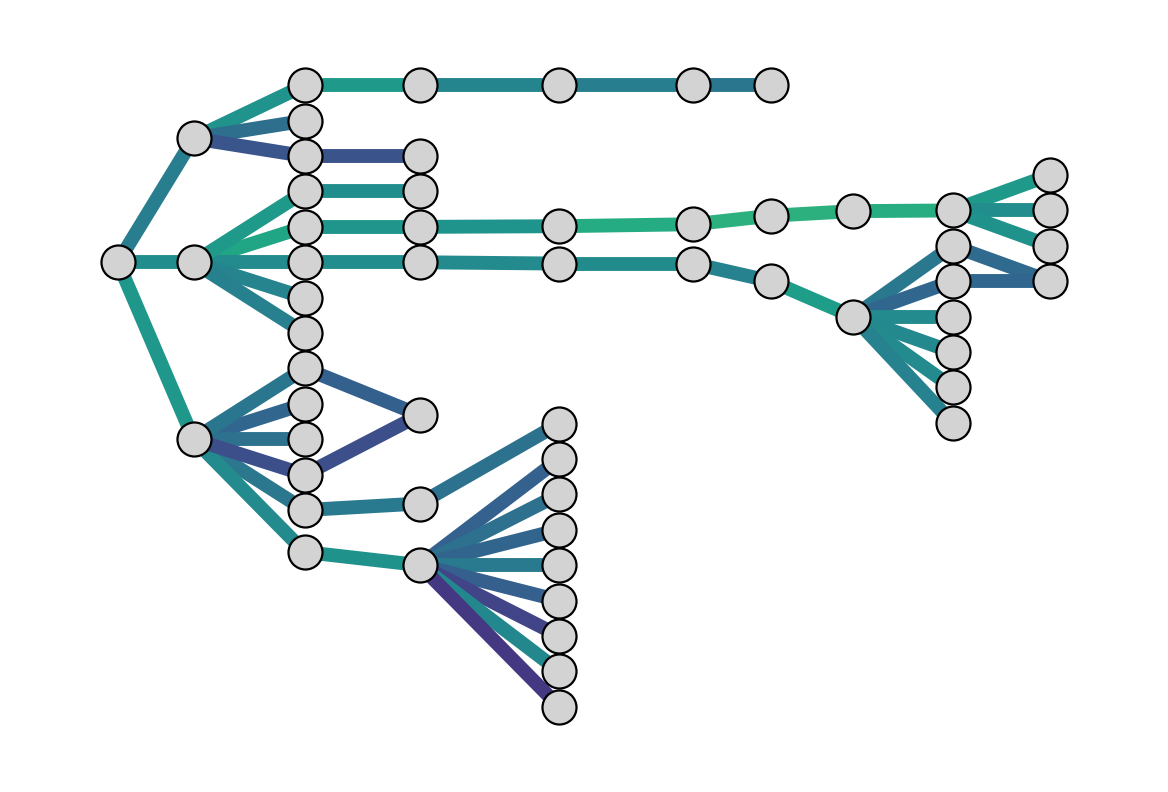

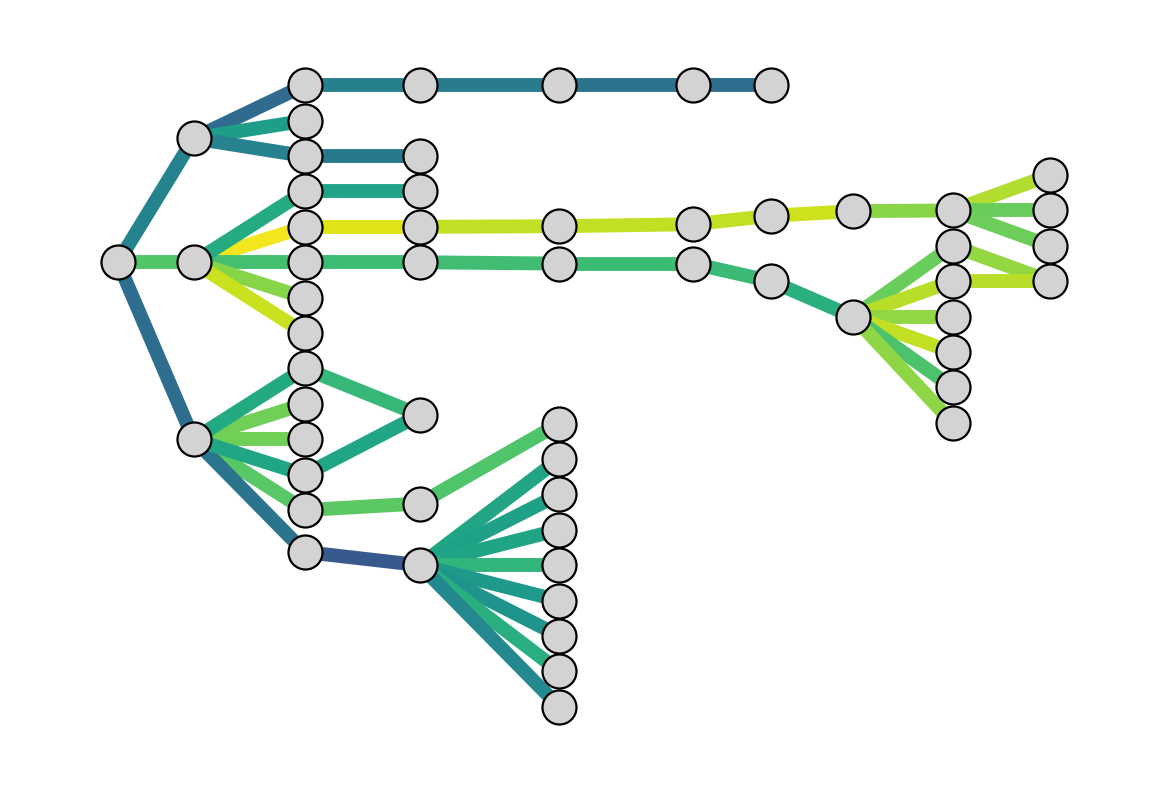

In [16]:
for i in ['weight_scpoli', 'weight_scvi']:
    plot_trajectory(
        trj, 
        figsize=(6, 4),
        edge_weight_attribute=i,
        title="", 
        edge_vmin=2.1,
        edge_vmax=3.5,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=False
    )

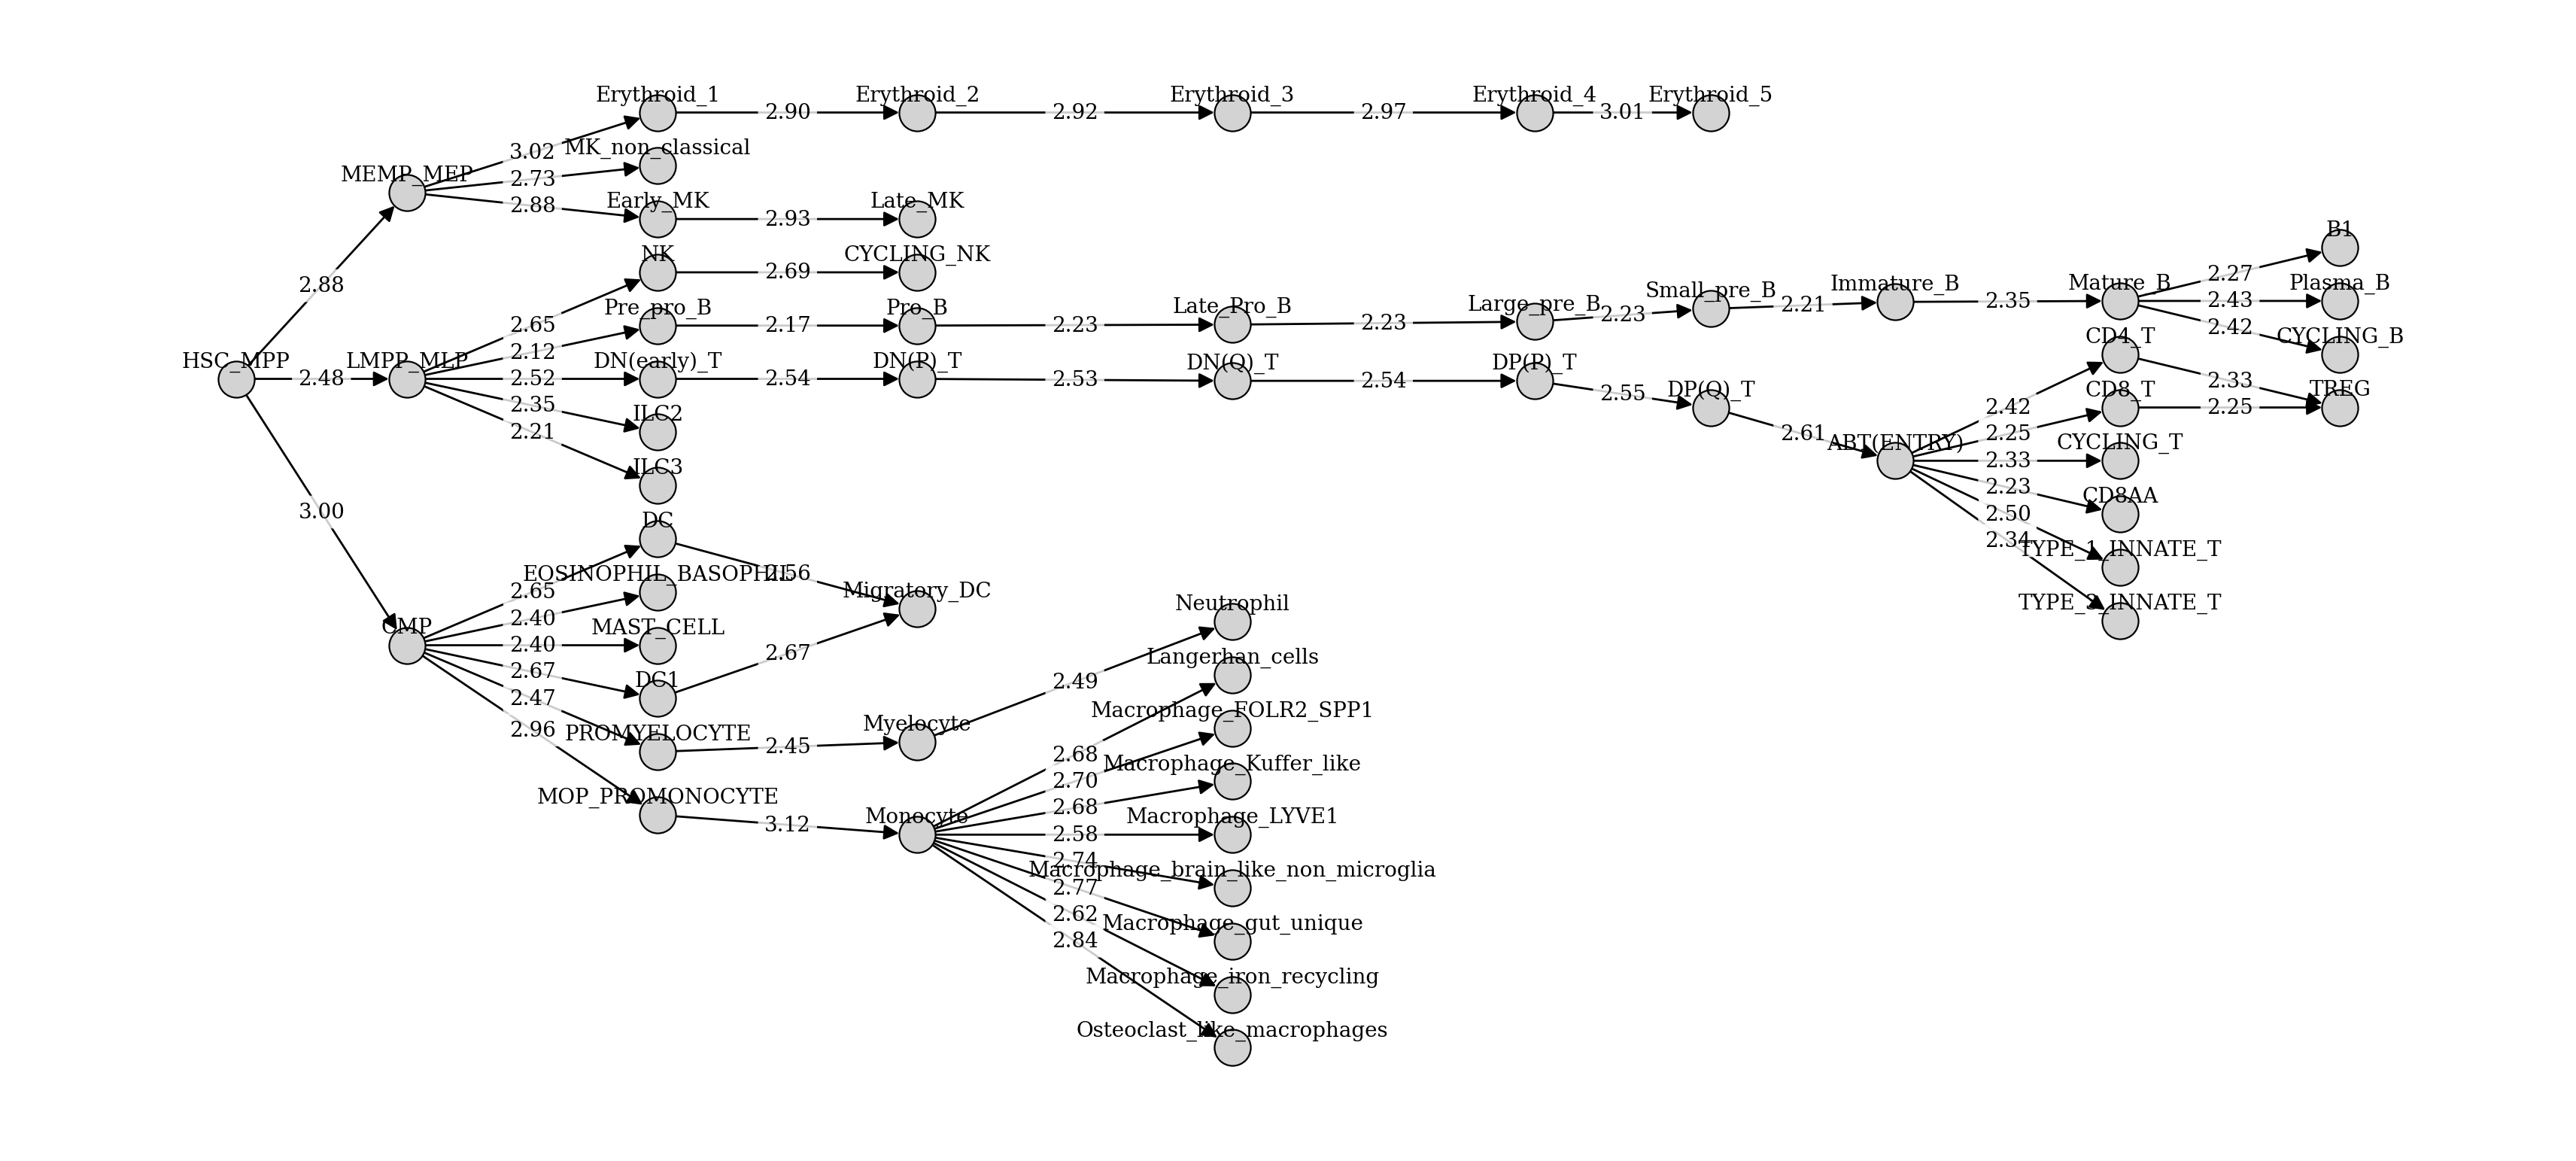

In [17]:
trj.plot_trajectory(
    figsize=(18, 8),
    edge_weight_attribute="weight_scvi",
    title=None, 
    color_edges_by_weight=False, 
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    edge_labels=True,
    edge_label_font_size=10,
    edge_colorbar=False,
    label_offset=18
)

### germline

In [18]:
for trajectory_focus, result_df in result_df_main.groupby('trajectory'):
    if trajectory_focus == "germline":
        decompose_method = "2"
        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            lit = pickle.load(_file)
        break

df_pivot = result_df.pivot(index=['trajectory', 'booted_trajectory', 'path', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_rank = df_pivot_rank.reset_index(drop=False, inplace=False).copy()

df_edges = []
for ind, row in result_df.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

df_edges_pivot = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()

trj = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, False)
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score

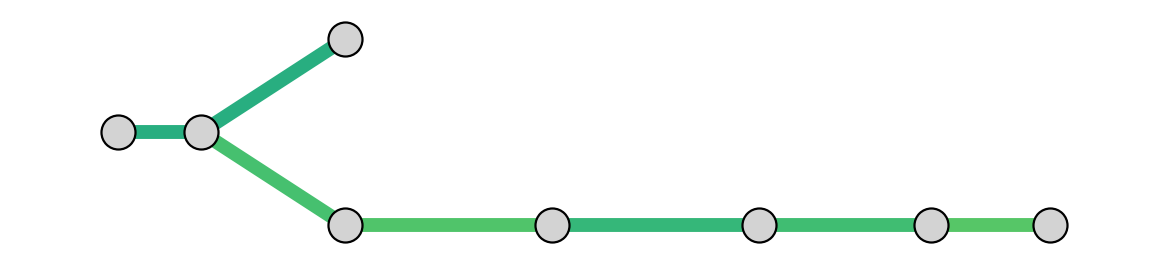

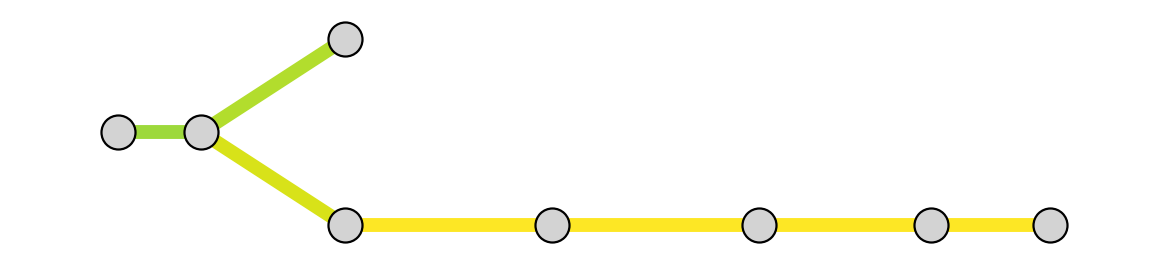

In [19]:
for i in ['weight_scpoli', 'weight_scvi']:
    plot_trajectory(
        trj, 
        figsize=(6, 1.2),
        edge_weight_attribute=i,
        title="", 
        edge_vmin=2.1,
        edge_vmax=3.5,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=False
    )

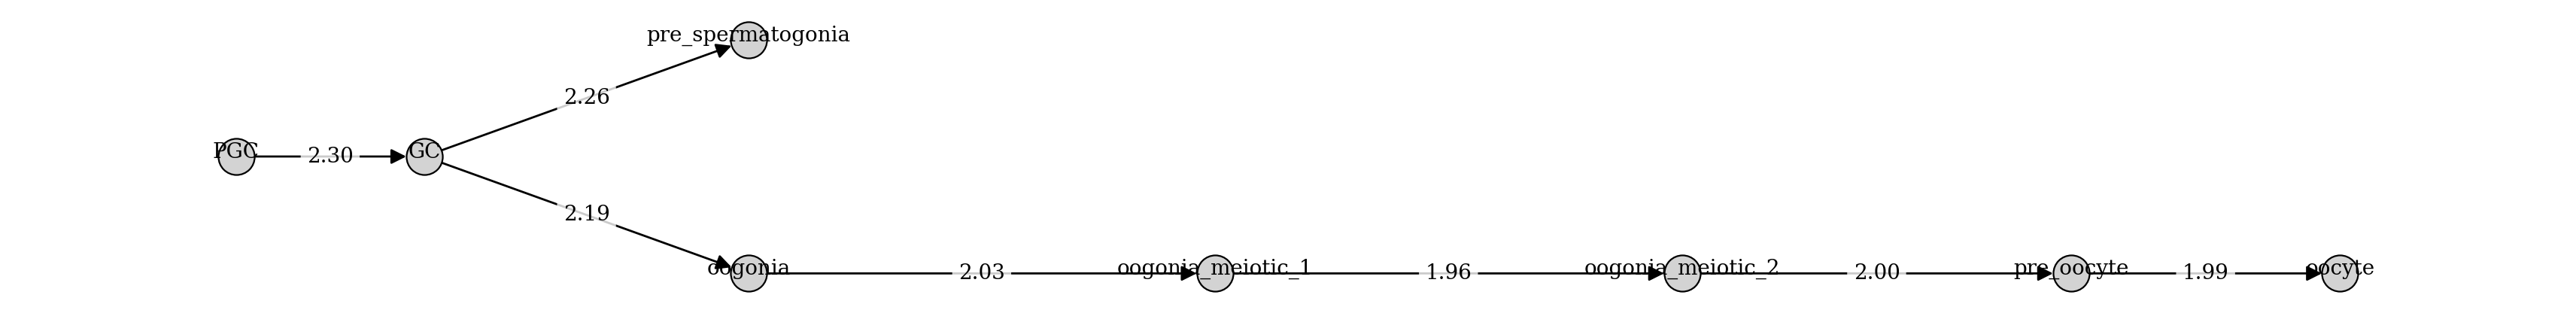

In [20]:
trj.plot_trajectory(
    figsize=(18, 2),
    edge_weight_attribute="weight_scvi",
    title=None, 
    color_edges_by_weight=False, 
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    edge_labels=True,
    edge_label_font_size=10,
    edge_colorbar=False,
    label_offset=1
)

### pns_neuro

In [21]:
for trajectory_focus, result_df in result_df_main.groupby('trajectory'):
    if trajectory_focus == "pns_neuro":
        decompose_method = "2"
        input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
        with open(input_trajectories_path_litc, 'rb') as _file:
            lit = pickle.load(_file)
        break

df_pivot = result_df.pivot(index=['trajectory', 'booted_trajectory', 'path', 'metric'], columns='representation', values='score')
df_pivot_rank = rank_metrics(df_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_rank = df_pivot_rank.reset_index(drop=False, inplace=False).copy()

df_edges = []
for ind, row in result_df.iterrows():
    trj = lit.get_trajectory(row["booted_trajectory"], False)
    for from_cell, to_cell in trj.edges():
        row_copy = row.copy()
        row_copy["from_cell"] = from_cell
        row_copy["to_cell"] = to_cell
        df_edges.append(row_copy)
df_edges = pd.DataFrame(df_edges)
df_edges.reset_index(drop=True, inplace=True)

df_edges_pivot = df_edges.pivot(index=['path', 'booted_trajectory', 'trajectory', 'metric', 'from_cell', 'to_cell'], columns='representation', values='score')
df_edges_pivot_rank = rank_metrics(df_edges_pivot, metric_direction_dict, metric_index_pos=3, method='min')
df_edges_pivot_rank_mean = df_edges_pivot_rank.groupby(level=[4, 5]).mean()

trj = InputTrajectories(ground_truth_trajectories).get_trajectory(trajectory_focus, False)
for (from_cell, to_cell), representations in df_edges_pivot_rank_mean.iterrows():
    for representation, score in representations.items():
        trj[from_cell][to_cell][f"weight_{representation}"] = score

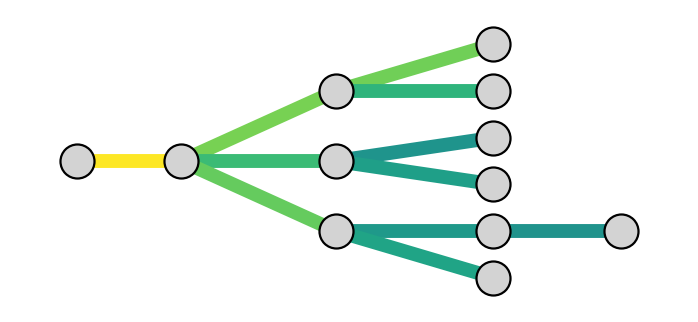

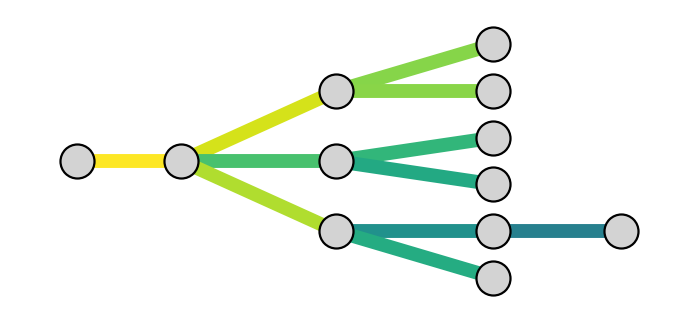

In [22]:
for i in ['weight_scpoli', 'weight_scvi']:
    plot_trajectory(
        trj, 
        figsize=(3.5, 1.5),
        edge_weight_attribute=i,
        title="", 
        edge_vmin=2.1,
        edge_vmax=3.5,
        color_edges_by_weight=True, 
        node_size=150, 
        node_color="lightgray", 
        edge_color='black',
        edge_width=5,
        edge_labels=False,
        edge_label_font_size=5,
        edge_cmap='viridis_r',
        edge_colorbar=False
    )

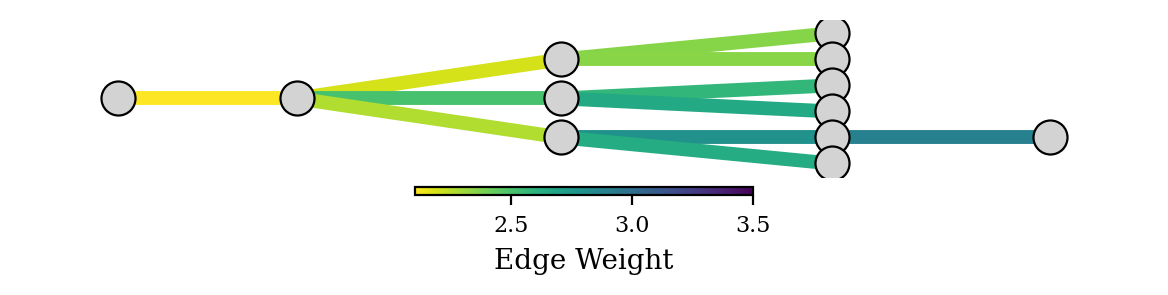

In [32]:
plot_trajectory(
    trj, 
    figsize=(6, 1.2),
    edge_weight_attribute=i,
    title="", 
    edge_vmin=2.1,
    edge_vmax=3.5,
    color_edges_by_weight=True, 
    node_size=150, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=5,
    edge_labels=False,
    edge_label_font_size=5,
    edge_cmap='viridis_r',
    edge_colorbar=True
)

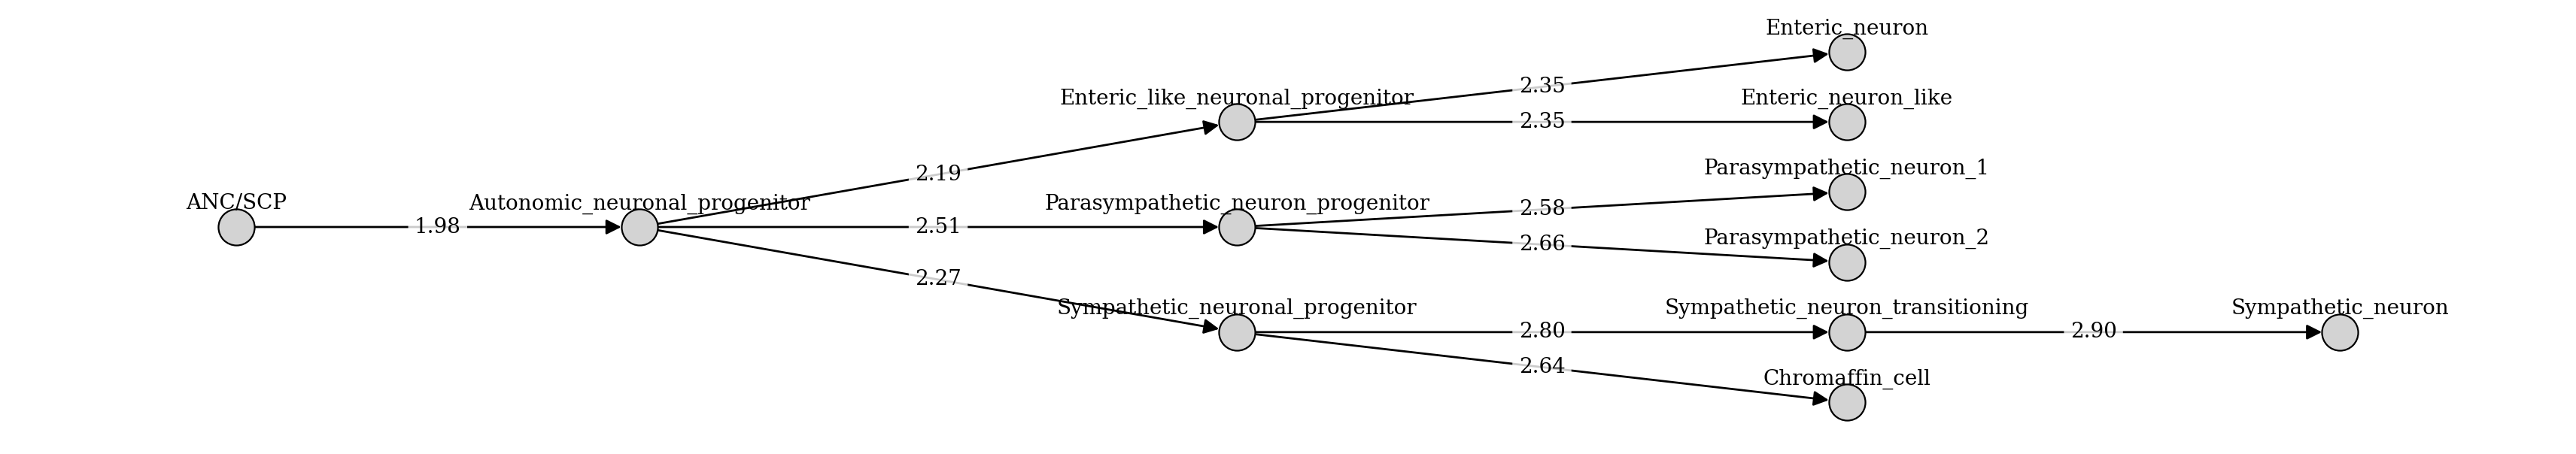

In [23]:
trj.plot_trajectory(
    figsize=(18, 3),
    edge_weight_attribute="weight_scvi",
    title=None, 
    color_edges_by_weight=False, 
    node_size=300, 
    node_color="lightgray", 
    edge_color='black',
    edge_width=1,
    edge_labels=True,
    edge_label_font_size=10,
    edge_colorbar=False,
    label_offset=18
)

# UMAPs

In [24]:
import scvelo as scv
import cellrank as cr
import scanpy.external as sce

scv.settings.verbosity = 3
cr.settings.verbosity = 2
sc.settings.verbose = 3

def cr_calc(adata_cr, root_cell_type, i, ann_levl):
    sc.tl.pca(adata_cr, n_comps=11, svd_solver='arpack')
    sce.tl.palantir(adata_cr, n_components=10, knn=30)

    root_cells = adata_cr.obs_names[adata_cr.obs[ann_levl] == root_cell_type]
    if len(root_cells) == 0:
        raise ValueError(f"No cells found with {ann_levl!r} == {root_cell_type!r}")
    start_cell = root_cells[i]
    
    pr_res = sce.tl.palantir_results(
        adata_cr,
        early_cell=start_cell,
        ms_data="X_palantir_multiscale",
        knn=30,
        num_waypoints=1200,
        n_jobs=-1
    )
    adata_cr.obs["palantir_pseudotime"] = pr_res.pseudotime

    pk = cr.kernels.PseudotimeKernel(adata_cr, time_key='palantir_pseudotime')
    pk.compute_transition_matrix()
    return pk    

## umap for pns_neuro

In [41]:
trajectory_focus = "pns_neuro"
decompose_method = "2"
input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)
ann_lvl = ground_truth_trajectories_annotation_level[trajectory_focus]




\%%%%%%%%%%%%%%


 scpoli
(3609265, 28)
(13377, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.05325065851211548 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6436169823010762 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9998
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/13377 [00:00<?, ?cell/s]

    Finish (0:00:05)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:03)


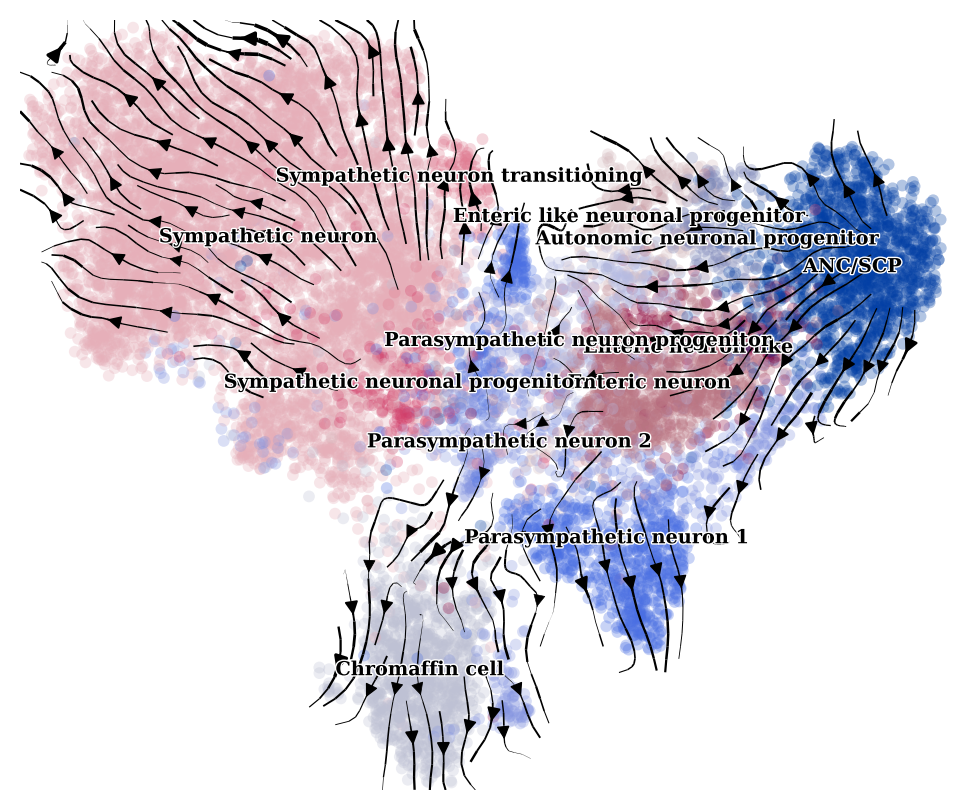




\%%%%%%%%%%%%%%


 scvi
(3609265, 28)
(13377, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.05165907939275106 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6177337686220805 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/13377 [00:00<?, ?cell/s]

    Finish (0:00:03)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


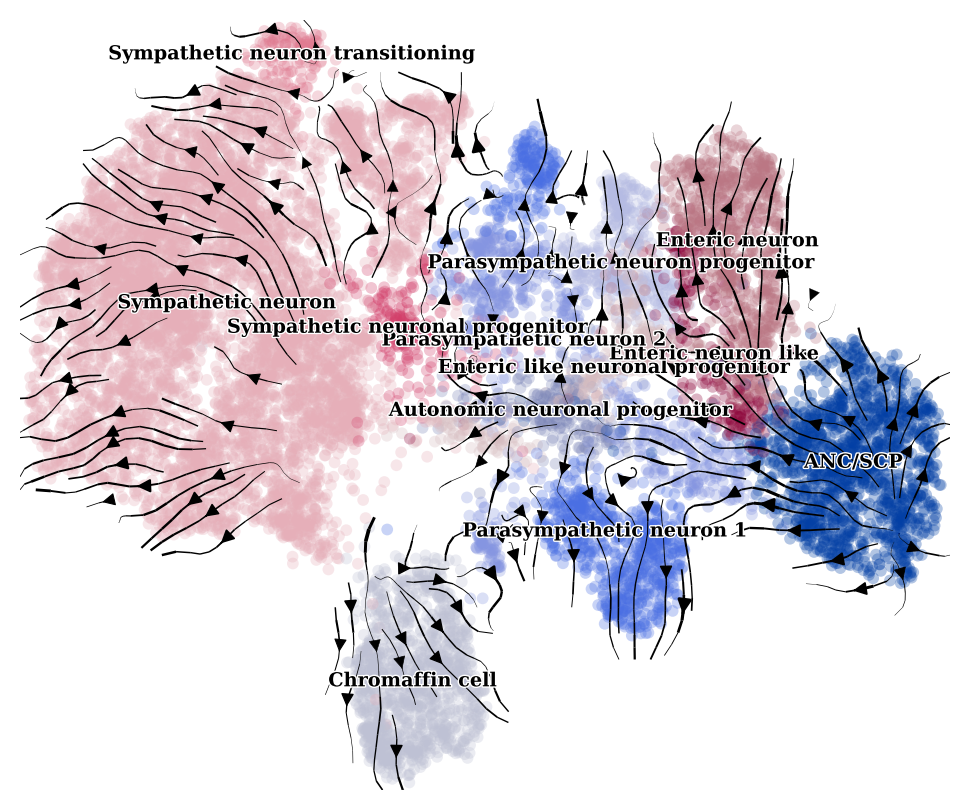

In [42]:
for use_rep in ['scpoli', 'scvi']:
    print("\n\n\n\%%%%%%%%%%%%%%\n\n\n", use_rep)
    adata_atlas = ad.read_h5ad(df_hdca_lvl3_adata_paths[use_rep]["latent"])
    print(adata_atlas.shape)
    adata_atlas.obs = out_df.copy()
    adata_atlas = adata_atlas[adata_atlas.obs[ann_lvl].isin(lit.nodes())]
    print(adata_atlas.shape)
    sc.pp.neighbors(adata_atlas)
    sc.tl.umap(adata_atlas)
    pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "ANC/SCP", i=10, ann_levl=ann_lvl)
    plt.figure(figsize=(6,5))
    pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="x-small")
    plt.show()
    del adata_atlas, pk_adata_atlas
    gc.collect()

## umap for germline

In [25]:
trajectory_focus = "germline"
decompose_method = "2"
input_trajectories_path_litc = os.path.join(dataset_dir, f"adata_hdca_input_{trajectory_focus}_litc_{decompose_method}.pkl")
with open(input_trajectories_path_litc, 'rb') as _file:
    lit = pickle.load(_file)
ann_lvl = ground_truth_trajectories_annotation_level[trajectory_focus]




\%%%%%%%%%%%%%%


 scpoli
(3609265, 28)
(11001, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.026261866092681885 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.8365996479988098 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/11001 [00:00<?, ?cell/s]

    Finish (0:00:03)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)


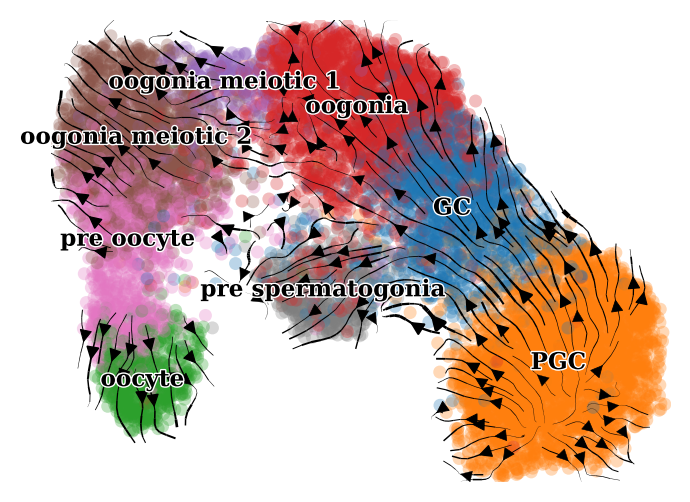




\%%%%%%%%%%%%%%


 scvi
(3609265, 28)
(11001, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.02403655449549357 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.62161226272583 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/11001 [00:00<?, ?cell/s]

    Finish (0:00:03)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)


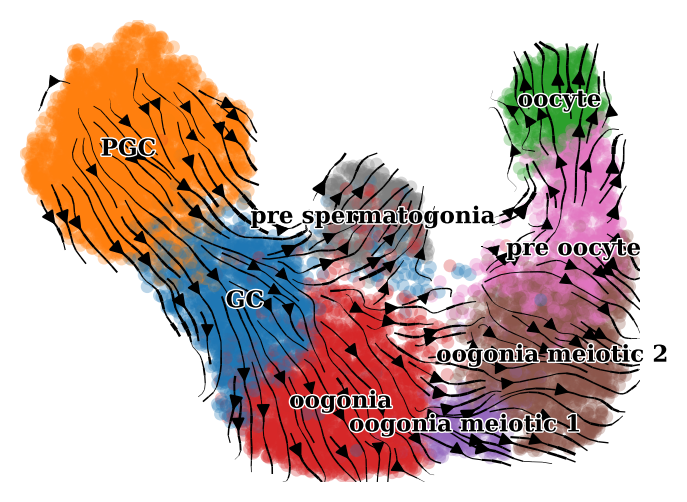

In [26]:
for use_rep in ['scpoli', 'scvi']:
    print("\n\n\n\%%%%%%%%%%%%%%\n\n\n", use_rep)
    adata_atlas = ad.read_h5ad(df_hdca_lvl3_adata_paths[use_rep]["latent"])
    print(adata_atlas.shape)
    adata_atlas.obs = out_df.copy()
    adata_atlas = adata_atlas[adata_atlas.obs[ann_lvl].isin(lit.nodes())]
    print(adata_atlas.shape)
    sc.pp.neighbors(adata_atlas)
    sc.tl.umap(adata_atlas)
    pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "PGC", i=10, ann_levl=ann_lvl)
    plt.figure(figsize=(4,3))
    pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="small")
    plt.show()
    del adata_atlas, pk_adata_atlas
    gc.collect()

## umap for hematopoietic parts

In [27]:
lineage_b = [
    ('HSC_MPP', 'LMPP_MLP'),
    ('LMPP_MLP', 'Pre_pro_B'),
    ('Pre_pro_B', 'Pro_B'),
    ('Pro_B', 'Late_Pro_B'),
    ('Late_Pro_B', 'Large_pre_B'),
    ('Large_pre_B', 'Small_pre_B'),
    ('Small_pre_B', 'Immature_B'),
    ('Immature_B', 'Mature_B'),
    ('Mature_B', 'B1'),
    ('Mature_B', 'Plasma_B'),
    ('Mature_B', 'CYCLING_B')
]

lineage_ery = [
    ('HSC_MPP', 'MEMP_MEP'),
    ('MEMP_MEP', 'Erythroid_1'),
    ('Erythroid_1', 'Erythroid_2'),
    ('Erythroid_2', 'Erythroid_3'),
    ('Erythroid_3', 'Erythroid_4'),
    ('Erythroid_4', 'Erythroid_5'),
    ('MEMP_MEP', 'MK_non_classical'),
    ('MEMP_MEP', 'Early_MK'),
    ('Early_MK', 'Late_MK'),
]

lineage_t = [
    ('HSC_MPP', 'LMPP_MLP'),
    ('LMPP_MLP', 'DN(early)_T'),
    ('DN(early)_T', 'DN(P)_T'),
    ('DN(P)_T', 'DN(Q)_T'),
    ('DN(Q)_T', 'DP(P)_T'),
    ('DP(P)_T', 'DP(Q)_T'),
    ('DP(Q)_T', 'ABT(ENTRY)'),
    ('ABT(ENTRY)', 'CD4_T'),
    ('ABT(ENTRY)', 'CD8_T'),
    ('ABT(ENTRY)', 'CYCLING_T'),
    ('ABT(ENTRY)', 'CD8AA'),
    ('ABT(ENTRY)', 'TYPE_1_INNATE_T'),
    ('ABT(ENTRY)', 'TYPE_3_INNATE_T'),
    ('CD4_T', 'TREG'),
    ('CD8_T', 'TREG'),
]

nodes_b = {i for j in lineage_b for i in j}
nodes_ery = {i for j in lineage_ery for i in j}
nodes_t = {i for j in lineage_t for i in j}
ann_lvl = ground_truth_trajectories_annotation_level["Haem_ref"]




\%%%%%%%%%%%%%%


 scpoli
(3609265, 28)
(10723, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.02792637745539347 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6212385614713033 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/10723 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:01)


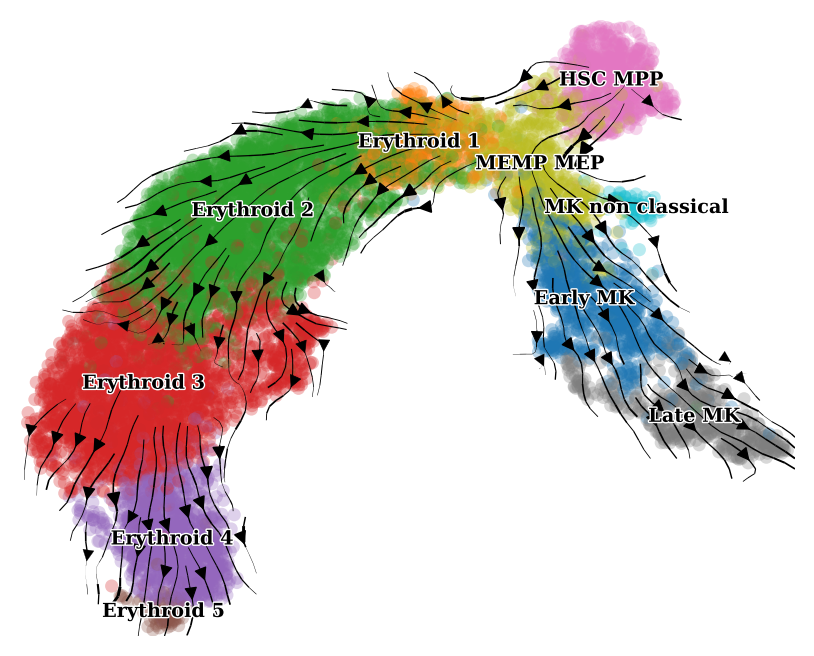




\%%%%%%%%%%%%%%


 scvi
(3609265, 28)
(10723, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.02177853584289551 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.610086989402771 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/10723 [00:00<?, ?cell/s]

    Finish (0:00:03)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


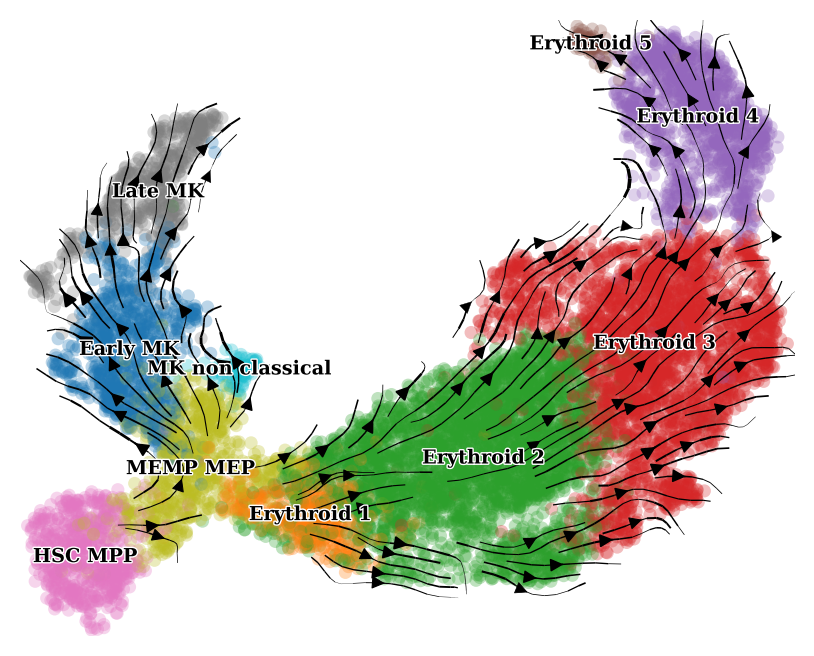

In [28]:
for use_rep in ['scpoli', 'scvi']:
    print("\n\n\n\%%%%%%%%%%%%%%\n\n\n", use_rep)
    adata_atlas = ad.read_h5ad(df_hdca_lvl3_adata_paths[use_rep]["latent"])
    print(adata_atlas.shape)
    adata_atlas.obs = out_df.copy()
    adata_atlas = adata_atlas[adata_atlas.obs[ann_lvl].isin(nodes_ery)]
    sc.pp.subsample(adata_atlas, fraction=0.10)
    print(adata_atlas.shape)
    sc.pp.neighbors(adata_atlas)
    sc.tl.umap(adata_atlas)
    pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "HSC_MPP", i=10, ann_levl=ann_lvl)
    plt.figure(figsize=(5,4))
    pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="x-small")
    plt.show()
    del adata_atlas, pk_adata_atlas
    gc.collect()




\%%%%%%%%%%%%%%


 scpoli
(3609265, 28)
(15280, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.04330787658691406 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6606695731480916 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9994
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/15280 [00:00<?, ?cell/s]

    Finish (0:00:03)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


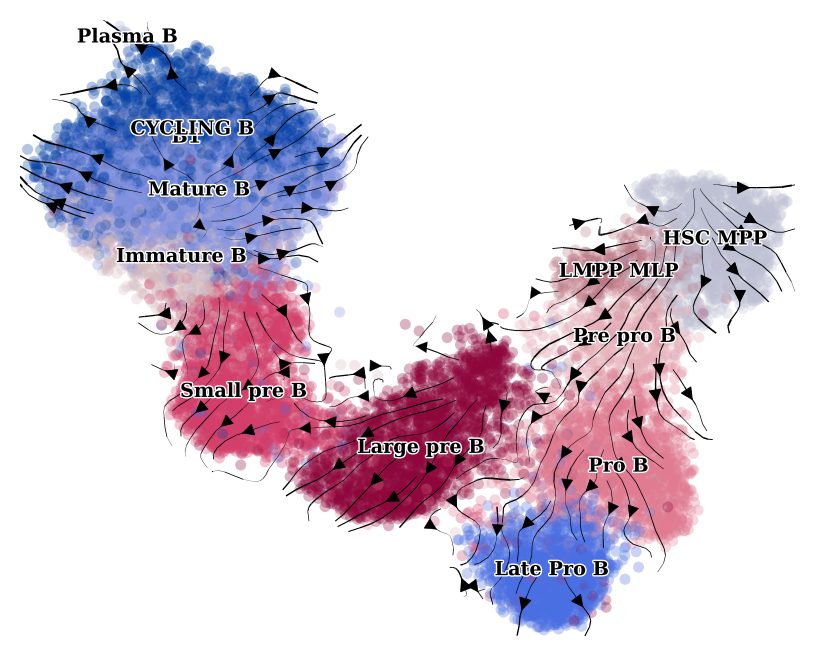




\%%%%%%%%%%%%%%


 scvi
(3609265, 28)
(15280, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.03487877448399861 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6603726545969645 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9996
Correlation at iteration 2: 1.0000
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/15280 [00:00<?, ?cell/s]

    Finish (0:00:04)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


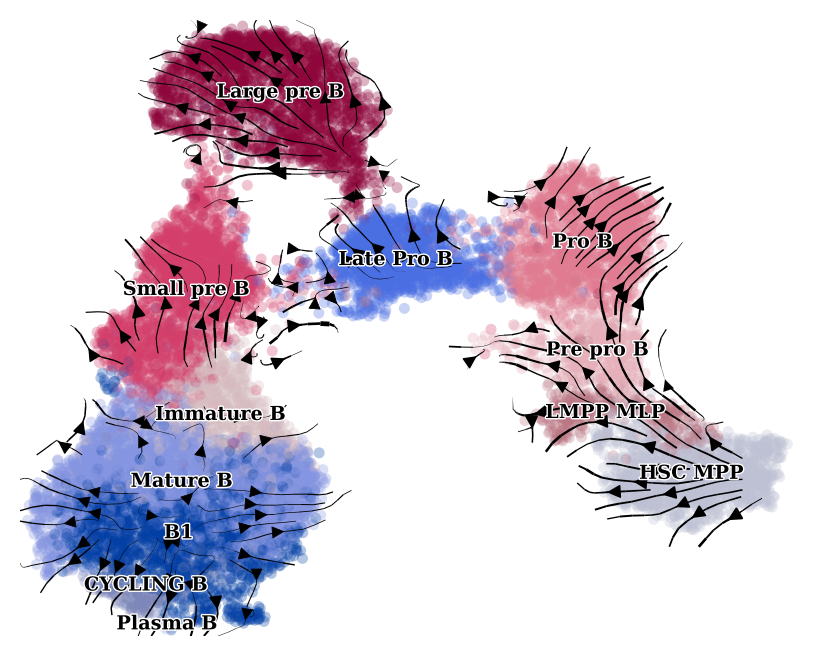

In [29]:
for use_rep in ['scpoli', 'scvi']:
    print("\n\n\n\%%%%%%%%%%%%%%\n\n\n", use_rep)
    adata_atlas = ad.read_h5ad(df_hdca_lvl3_adata_paths[use_rep]["latent"])
    print(adata_atlas.shape)
    adata_atlas.obs = out_df.copy()
    adata_atlas = adata_atlas[adata_atlas.obs[ann_lvl].isin(nodes_b)]
    sc.pp.subsample(adata_atlas, fraction=0.2)
    print(adata_atlas.shape)
    sc.pp.neighbors(adata_atlas)
    sc.tl.umap(adata_atlas)
    pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "HSC_MPP", i=10, ann_levl=ann_lvl)
    plt.figure(figsize=(5,4))
    pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="x-small")
    plt.show()
    del adata_atlas, pk_adata_atlas
    gc.collect()




\%%%%%%%%%%%%%%


 scpoli
(3609265, 28)
(12441, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.06602391799290976 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6194599429766338 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/12441 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


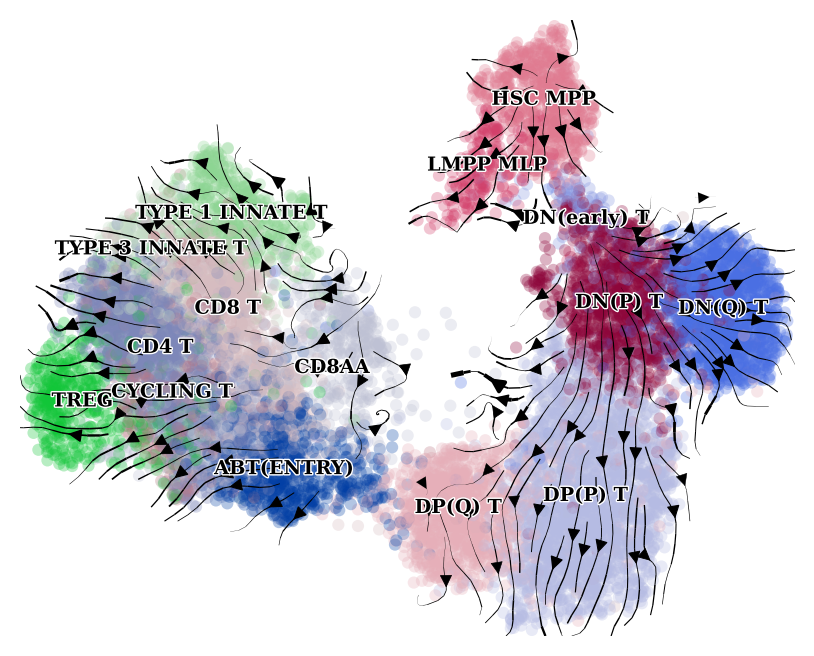




\%%%%%%%%%%%%%%


 scvi
(3609265, 28)
(12441, 28)
Sampling and flocking waypoints...
Time for determining waypoints: 0.02790219783782959 minutes
Determining pseudotime...
Shortest path distances using 30-nearest neighbor graph...
Time for shortest paths: 0.6282483458518981 minutes
Iteratively refining the pseudotime...
Correlation at iteration 1: 0.9990
Correlation at iteration 2: 0.9999
Entropy and branch probabilities...
Markov chain construction...
Identification of terminal states...
Computing fundamental matrix and absorption probabilities...
Project results to all cells...
Computing transition matrix based on pseudotime


  0%|          | 0/12441 [00:00<?, ?cell/s]

    Finish (0:00:02)
Projecting transition matrix onto `umap`
Adding `adata.obsm['T_fwd_umap']`
    Finish (0:00:02)


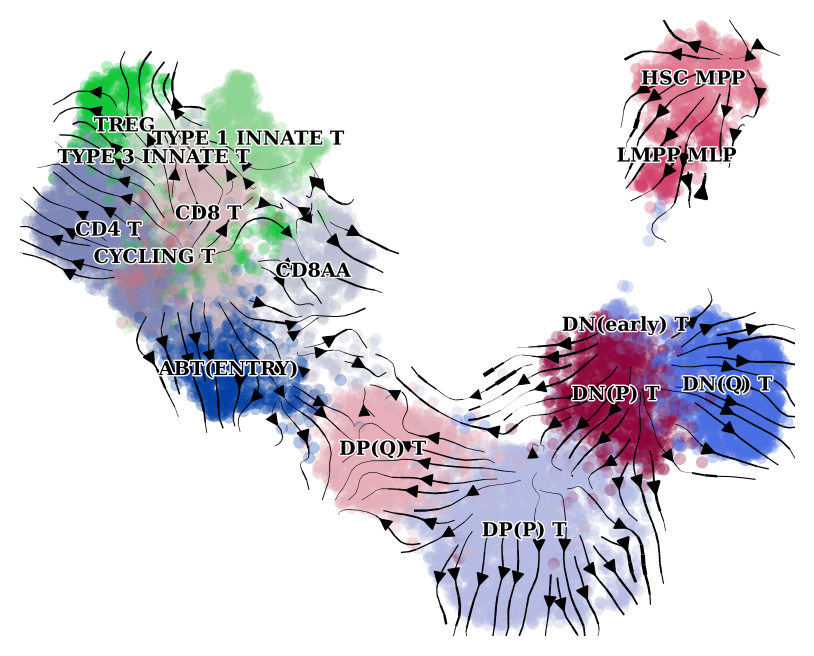

In [30]:
for use_rep in ['scpoli', 'scvi']:
    print("\n\n\n\%%%%%%%%%%%%%%\n\n\n", use_rep)
    adata_atlas = ad.read_h5ad(df_hdca_lvl3_adata_paths[use_rep]["latent"])
    print(adata_atlas.shape)
    adata_atlas.obs = out_df.copy()
    adata_atlas = adata_atlas[adata_atlas.obs[ann_lvl].isin(nodes_t)]
    sc.pp.subsample(adata_atlas, fraction=0.10)
    print(adata_atlas.shape)
    sc.pp.neighbors(adata_atlas)
    sc.tl.umap(adata_atlas)
    pk_adata_atlas = cr_calc(adata_atlas.copy(), root_cell_type = "HSC_MPP", i=10, ann_levl=ann_lvl)
    plt.figure(figsize=(5,4))
    pk_adata_atlas.plot_projection(basis='umap', recompute=False, color=[ann_lvl], title="", ax=plt.gca(), legend_fontsize="x-small")
    plt.show()
    del adata_atlas, pk_adata_atlas
    gc.collect()